# 2.1 理论计算题

### 1. 非线性激活函数的重要性

**证明：**
隐藏层（无激活）：
$$
\boldsymbol{h} = \boldsymbol{W}_1 \boldsymbol{x} + \boldsymbol{b}_1
$$

输出层：
$$
\boldsymbol{o} = \boldsymbol{W}_2 \boldsymbol{h} + \boldsymbol{b}_2
$$

代入展开：
$$
\boldsymbol{o} = \boldsymbol{W}_2 (\boldsymbol{W}_1 \boldsymbol{x} + \boldsymbol{b}_1) + \boldsymbol{b}_2
$$

合并：
$$
\boldsymbol{o} = (\boldsymbol{W}_2 \boldsymbol{W}_1)\boldsymbol{x} + (\boldsymbol{W}_2 \boldsymbol{b}_1 + \boldsymbol{b}_2)
$$

令：
$$
\boldsymbol{W}' = \boldsymbol{W}_2 \boldsymbol{W}_1,\quad \boldsymbol{b}' = \boldsymbol{W}_2 \boldsymbol{b}_1 + \boldsymbol{b}_2
$$

得到：
$$
\boldsymbol{o} = \boldsymbol{W}' \boldsymbol{x} + \boldsymbol{b}'
$$

**结论：**
无论多少层线性网络，最终都等价于**单层线性模型**，没有任何非线性表达能力。
只有加入**非线性激活函数**，多层网络才能拟合复杂分布，这就是激活函数的核心意义。


### 2. 激活函数性质分析

#### Sigmoid
定义：
$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$

导数：
$$
\sigma'(x) = \sigma(x)(1-\sigma(x))
$$

**详细说明：**
- 输出范围 (0,1)，常用于表示概率
- 导数只依赖自身，计算极快
- 大输入时导数趋近 0，容易导致**梯度消失**


#### Tanh
定义：
$$
\tanh(x) = \frac{e^x - e^{-x}}{e^x + e^{-x}}
$$

导数：
$$
\tanh'(x) = 1 - \tanh^2(x)
$$

**详细说明：**
- 输出范围 (-1,1)，均值为 0，比 Sigmoid 更稳定
- 同样存在大输入梯度趋近 0 的问题
- 常用于循环神经网络（RNN/LSTM）

使用设备: cpu
加载Fashion-MNIST数据集...
输入维度：784
隐藏层维度：256
输出类别数：10

参数初始化完成（正态分布 N(0, 0.01²)）

开始训练...
Epoch 2/10 | Train Loss: 0.4910 | Train Acc: 0.8212 | Test Acc: 0.7886
Epoch 4/10 | Train Loss: 0.4056 | Train Acc: 0.8525 | Test Acc: 0.8395
Epoch 6/10 | Train Loss: 0.3684 | Train Acc: 0.8665 | Test Acc: 0.8526
Epoch 8/10 | Train Loss: 0.3433 | Train Acc: 0.8752 | Test Acc: 0.8292
Epoch 10/10 | Train Loss: 0.3247 | Train Acc: 0.8825 | Test Acc: 0.8556

最终测试准确率：0.8556


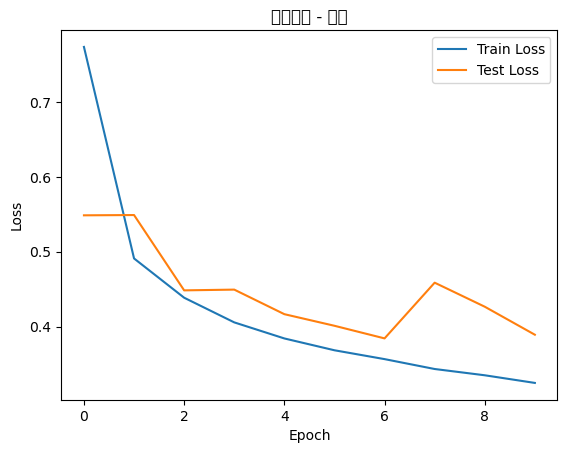

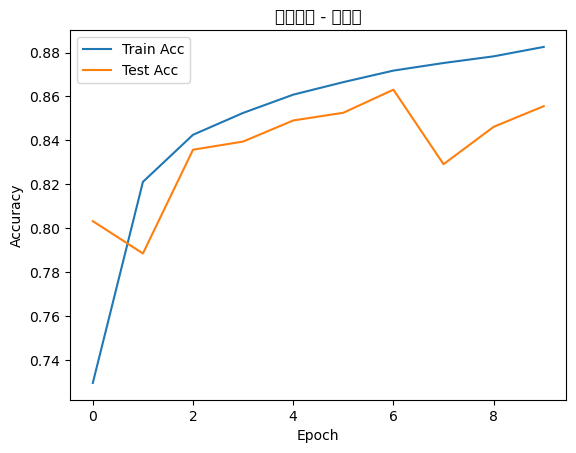

In [7]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

def load_data_fashion_mnist(batch_size):
    print("加载Fashion-MNIST数据集...")
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def init_params(input_size, hidden_size, output_size):
    print(f"输入维度：{input_size}")
    print(f"隐藏层维度：{hidden_size}")
    print(f"输出类别数：{output_size}")
    W1 = torch.normal(0, 0.01, size=(input_size, hidden_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(hidden_size, output_size), device=device, requires_grad=False)
    b2 = torch.zeros(output_size, device=device, requires_grad=False)
    print("\n参数初始化完成（正态分布 N(0, 0.01²)）\n")
    return W1, b1, W2, b2

def relu(X):
    return torch.max(X, torch.tensor(0.0, device=X.device))

def softmax_cross_entropy(logits, y):
    logits_exp = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
    probs = logits_exp / logits_exp.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss, probs

def forward(X, W1, b1, W2, b2):
    h = relu(torch.mm(X, W1) + b1)
    out = torch.mm(h, W2) + b2
    return out, h

def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

def train_epoch(train_loader, W1, b1, W2, b2, lr):
    total_loss, total_acc, num_samples = 0.0, 0.0, 0
    for X, y in train_loader:
        X, y = X.view(-1, 784).to(device), y.to(device)
        logits, h = forward(X, W1, b1, W2, b2)
        loss, probs = softmax_cross_entropy(logits, y)
        batch_size = X.shape[0]
        one_hot = torch.zeros_like(probs)
        one_hot[range(batch_size), y] = 1
        d_logits = (probs - one_hot) / batch_size
        d_W2 = torch.mm(h.T, d_logits)
        d_b2 = d_logits.sum(dim=0)
        d_h = torch.mm(d_logits, W2.T)
        d_h[relu(h) <= 0] = 0
        d_W1 = torch.mm(X.T, d_h)
        d_b1 = d_h.sum(dim=0)
        with torch.no_grad():
            W1 -= lr * d_W1
            b1 -= lr * d_b1
            W2 -= lr * d_W2
            b2 -= lr * d_b2
        total_loss += loss.item() * batch_size
        total_acc += accuracy(logits, y) * batch_size
        num_samples += batch_size
    return total_loss / num_samples, total_acc / num_samples

def evaluate(test_loader, W1, b1, W2, b2):
    total_loss, total_acc, num_samples = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.view(-1, 784).to(device), y.to(device)
            logits, _ = forward(X, W1, b1, W2, b2)
            loss, _ = softmax_cross_entropy(logits, y)
            total_loss += loss.item() * X.shape[0]
            total_acc += accuracy(logits, y) * X.shape[0]
            num_samples += X.shape[0]
    return total_loss / num_samples, total_acc / num_samples

def train_mlp(batch_size=256, hidden_size=256, lr=0.1, epochs=10):
    train_loader, test_loader = load_data_fashion_mnist(batch_size)
    input_size = 28*28
    output_size = 10
    W1, b1, W2, b2 = init_params(input_size, hidden_size, output_size)
    
    train_losses, test_losses = [], []
    train_accs, test_accs = [], []
    
    print("开始训练...")
    for epoch in range(1, epochs+1):
        train_loss, train_acc = train_epoch(train_loader, W1, b1, W2, b2, lr)
        test_loss, test_acc = evaluate(test_loader, W1, b1, W2, b2)
        train_losses.append(train_loss)
        test_losses.append(test_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        if epoch % 2 == 0 or epoch == epochs:
            print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | Test Acc: {test_acc:.4f}")
    
    print(f"\n最终测试准确率：{test_accs[-1]:.4f}")
    
    plt.figure()
    plt.plot(train_losses, label='Train Loss')
    plt.plot(test_losses, label='Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('训练曲线 - 损失')
    plt.legend()
    plt.show()
    
    plt.figure()
    plt.plot(train_accs, label='Train Acc')
    plt.plot(test_accs, label='Test Acc')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('训练曲线 - 准确率')
    plt.legend()
    plt.show()

if __name__ == '__main__':
    train_mlp()

# 3.1 理论计算题

### 1. 训练误差与泛化误差

**训练误差：**
模型在**训练集**上的误差，反映模型对训练数据的拟合程度。

**泛化误差：**
模型在**从未见过的新数据**上的期望误差，反映模型的真实预测能力。

**状态判断：**
训练误差极低、泛化误差很高 → **过拟合（Overfitting）**

**缓解方法：**
- 降低模型复杂度
- 增加训练数据
- 使用 L2 正则化（权重衰减）
- 使用 Dropout
- 早停（Early Stopping）


### 2. K 折交叉验证（K-fold Cross-Validation）

**步骤：**
1. 将训练集随机分成 **K 个大小相同**的子集。
2. 依次取 **1 份做验证集**，剩下 K−1 份做训练集。
3. 训练模型并记录验证误差。
4. 重复 K 次，取**平均验证误差**作为模型性能。

**作用：**
- 不浪费测试集
- 更稳定、更可靠地评估模型
- 常用于超参数选择（学习率、正则化系数等）

使用设备: cpu

--- No Regularization ---
Epoch 10/100 | Train Loss: 2.0927 | Test Loss: 2.0965
Epoch 20/100 | Train Loss: 1.7538 | Test Loss: 1.7816
Epoch 30/100 | Train Loss: 1.4184 | Test Loss: 1.4808
Epoch 40/100 | Train Loss: 1.1728 | Test Loss: 1.2668
Epoch 50/100 | Train Loss: 1.0034 | Test Loss: 1.1223
Epoch 60/100 | Train Loss: 0.8820 | Test Loss: 1.0212
Epoch 70/100 | Train Loss: 0.7913 | Test Loss: 0.9486
Epoch 80/100 | Train Loss: 0.7212 | Test Loss: 0.8957
Epoch 90/100 | Train Loss: 0.6655 | Test Loss: 0.8563
Epoch 100/100 | Train Loss: 0.6195 | Test Loss: 0.8264

--- Weight Decay (λ=1e-3) ---
Epoch 10/100 | Train Loss: 2.0871 | Test Loss: 2.0960
Epoch 20/100 | Train Loss: 1.7346 | Test Loss: 1.7710
Epoch 30/100 | Train Loss: 1.3867 | Test Loss: 1.4605
Epoch 40/100 | Train Loss: 1.1454 | Test Loss: 1.2503
Epoch 50/100 | Train Loss: 0.9832 | Test Loss: 1.1122
Epoch 60/100 | Train Loss: 0.8669 | Test Loss: 1.0161
Epoch 70/100 | Train Loss: 0.7794 | Test Loss: 0.9471
Epoch 80/100 

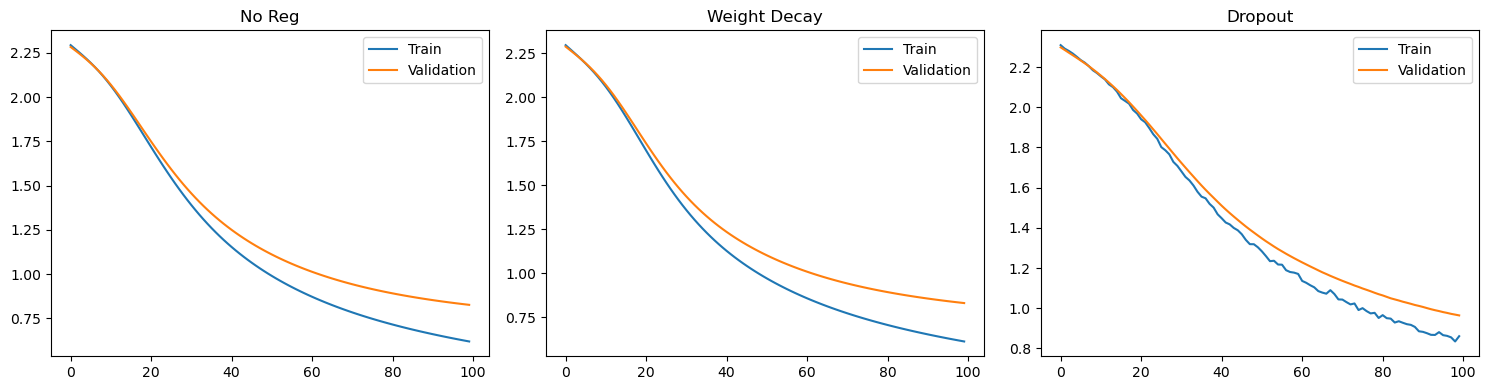

In [8]:
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}")

def load_data_fashion_mnist(batch_size):
    transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
    train_set = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
    test_set = torchvision.datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)
    train_loader = torch.utils.data.DataLoader(train_set, batch_size=batch_size, shuffle=True)
    test_loader = torch.utils.data.DataLoader(test_set, batch_size=batch_size, shuffle=False)
    return train_loader, test_loader

def init_params(input_size, hidden_size, output_size):
    W1 = torch.normal(0, 0.01, size=(input_size, hidden_size), device=device, requires_grad=False)
    b1 = torch.zeros(hidden_size, device=device, requires_grad=False)
    W2 = torch.normal(0, 0.01, size=(hidden_size, output_size), device=device, requires_grad=False)
    b2 = torch.zeros(output_size, device=device, requires_grad=False)
    return W1, b1, W2, b2

def relu(X):
    return torch.max(X, torch.tensor(0.0, device=X.device))

def softmax_cross_entropy(logits, y):
    logits_exp = torch.exp(logits - logits.max(dim=1, keepdim=True)[0])
    probs = logits_exp / logits_exp.sum(dim=1, keepdim=True)
    loss = -torch.log(probs[range(len(y)), y] + 1e-8).mean()
    return loss, probs

def dropout_layer(X, dropout, is_training=True):
    if not is_training or dropout == 0:
        return X
    mask = (torch.rand(X.shape, device=X.device) > dropout).float()
    return X * mask / (1.0 - dropout)

def forward_with_dropout(X, W1, b1, W2, b2, dropout, is_training):
    h = relu(torch.mm(X, W1) + b1)
    h = dropout_layer(h, dropout, is_training)
    out = torch.mm(h, W2) + b2
    return out, h

def accuracy(y_hat, y):
    return (y_hat.argmax(dim=1) == y).float().mean().item()

def evaluate(test_loader, W1, b1, W2, b2, dropout=0):
    total_loss, total_acc, num_samples = 0.0, 0.0, 0
    with torch.no_grad():
        for X, y in test_loader:
            X, y = X.view(-1, 784).to(device), y.to(device)
            logits, _ = forward_with_dropout(X, W1, b1, W2, b2, dropout, is_training=False)
            loss, _ = softmax_cross_entropy(logits, y)
            total_loss += loss.item() * X.shape[0]
            total_acc += accuracy(logits, y) * X.shape[0]
            num_samples += X.shape[0]
    return total_loss / num_samples, total_acc / num_samples

def compare_regularization():
    batch_size = 64
    hidden_size = 512
    lr = 0.01
    epochs = 100
    full_train_loader, test_loader = load_data_fashion_mnist(batch_size)
    small_train_data = []
    for i, (X, y) in enumerate(full_train_loader):
        if i * batch_size >= 200:
            break
        small_train_data.append((X, y))
    
    def run_experiment(weight_decay, dropout, name):
        print(f"\n--- {name} ---")
        W1, b1, W2, b2 = init_params(28*28, hidden_size, 10)
        train_losses, test_losses = [], []
        for epoch in range(1, epochs+1):
            total_loss, total_acc, num = 0.0, 0.0, 0
            for X, y in small_train_data:
                X, y = X.view(-1, 784).to(device), y.to(device)
                logits, h = forward_with_dropout(X, W1, b1, W2, b2, dropout, is_training=True)
                loss, probs = softmax_cross_entropy(logits, y)
                batch_size_curr = X.shape[0]
                one_hot = torch.zeros_like(probs)
                one_hot[range(batch_size_curr), y] = 1
                d_logits = (probs - one_hot) / batch_size_curr
                d_W2 = torch.mm(h.T, d_logits) + weight_decay * W2
                d_b2 = d_logits.sum(dim=0)
                d_h = torch.mm(d_logits, W2.T)
                d_h[relu(h) <= 0] = 0
                d_W1 = torch.mm(X.T, d_h) + weight_decay * W1
                d_b1 = d_h.sum(dim=0)
                with torch.no_grad():
                    W1 -= lr * d_W1
                    b1 -= lr * d_b1
                    W2 -= lr * d_W2
                    b2 -= lr * d_b2
                total_loss += loss.item() * batch_size_curr
                total_acc += accuracy(logits, y) * batch_size_curr
                num += batch_size_curr
            train_loss = total_loss / num
            test_loss, _ = evaluate(test_loader, W1, b1, W2, b2, dropout=0)
            train_losses.append(train_loss)
            test_losses.append(test_loss)
            if epoch % 10 == 0:
                print(f"Epoch {epoch}/{epochs} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")
        return train_losses, test_losses
    
    t1, v1 = run_experiment(weight_decay=0.0, dropout=0.0, name="No Regularization")
    t2, v2 = run_experiment(weight_decay=1e-3, dropout=0.0, name="Weight Decay (λ=1e-3)")
    t3, v3 = run_experiment(weight_decay=0.0, dropout=0.5, name="Dropout (p=0.5)")
    
    plt.figure(figsize=(15,4))
    plt.subplot(1,3,1); plt.plot(t1, label='Train'); plt.plot(v1, label='Validation'); plt.title('No Reg'); plt.legend()
    plt.subplot(1,3,2); plt.plot(t2, label='Train'); plt.plot(v2, label='Validation'); plt.title('Weight Decay'); plt.legend()
    plt.subplot(1,3,3); plt.plot(t3, label='Train'); plt.plot(v3, label='Validation'); plt.title('Dropout'); plt.legend()
    plt.tight_layout()
    plt.show()

if __name__ == '__main__':
    compare_regularization()

# 4.1 理论计算题

### 1. 梯度消失与梯度爆炸

深层网络梯度包含连乘项：
$$
\prod_{i=t}^{d-1} \frac{\partial h^{i+1}}{\partial h^i}
$$

**梯度消失：**
每一层梯度的**奇异值 < 1**，连乘后指数级变小 → 梯度趋近 0。
常见于：Sigmoid / tanh 深层网络、权重初始化过小。

**梯度爆炸：**
每一层梯度的**奇异值 > 1**，连乘后指数级变大 → 数值溢出 NaN。
常见于：权重初始化过大、深层网络无约束。

**危害：**
- 梯度消失：浅层无法学习
- 梯度爆炸：训练崩溃


### 2. ReLU 为何缓解梯度消失

ReLU 定义：
$$
\text{ReLU}(x) = \max(0, x)
$$

导数：
$$
\text{ReLU}'(x) = \begin{cases} 1 & x>0 \\ 0 & x\le 0 \end{cases}
$$

**原理：**
- x>0 时导数恒为 **1**
- 反向传播时梯度**不会衰减**，能稳定传到浅层
- 计算极快，大幅提升训练速度

**说明：**
ReLU 会出现“死神经元”（输入恒负、永不更新），可用 LeakyReLU 修复。

使用设备: cpu

实验1：Sigmoid + 高斯初始化
梯度范数: 最小 1.57e+02, 最大 3.67e+04

实验2：ReLU + 大初始化
梯度范数极大: nan

实验3：Xavier + LeakyReLU
梯度稳定: 最小 5.82e-02, 最大 2.02e+02


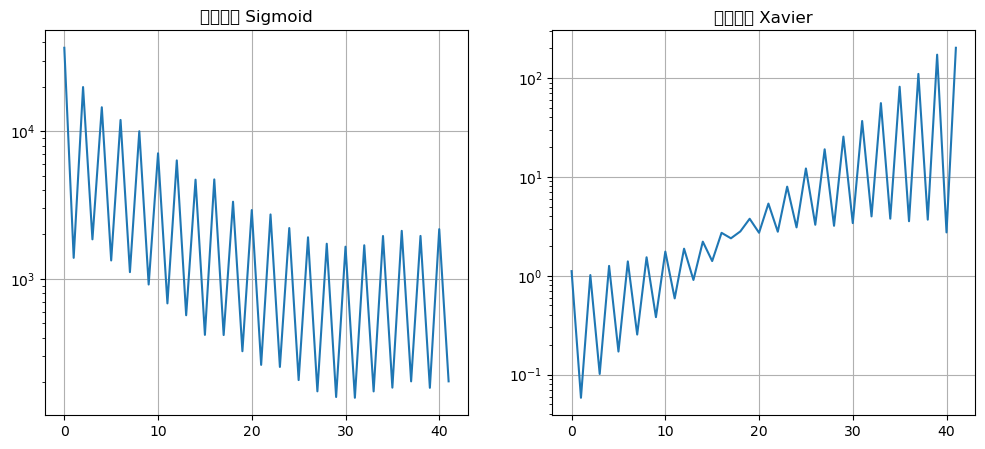

In [9]:
import torch
import torch.nn as nn
import torch.nn.init as init
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用设备: {device}\n")

class DeepNet(nn.Module):
    def __init__(self, num_hidden_layers=20, hidden_dim=256, activation='sigmoid'):
        super().__init__()
        self.num_hidden_layers = num_hidden_layers
        self.activation_name = activation
        layers = []
        in_dim = 784
        for _ in range(num_hidden_layers):
            layers.append(nn.Linear(in_dim, hidden_dim))
            in_dim = hidden_dim
        layers.append(nn.Linear(hidden_dim, 10))
        self.net = nn.Sequential(*layers)
    
    def forward(self, x):
        for i, layer in enumerate(self.net):
            x = layer(x)
            if i < self.num_hidden_layers:
                if self.activation_name == 'sigmoid':
                    x = torch.sigmoid(x)
                elif self.activation_name == 'relu':
                    x = torch.relu(x)
                elif self.activation_name == 'leaky_relu':
                    x = torch.nn.functional.leaky_relu(x, 0.01)
        return x

def compute_grad_norms(model, input_data):
    model.train()
    input_data.requires_grad_(True)
    output = model(input_data)
    loss = output.sum()
    loss.backward()
    grad_norms = []
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_norms.append(param.grad.norm().item())
    return grad_norms

print("=" * 60)
print("实验1：Sigmoid + 高斯初始化")
print("=" * 60)
model1 = DeepNet(20, 256, 'sigmoid')
def init_normal(m):
    if isinstance(m, nn.Linear):
        init.normal_(m.weight, 0, 1.0)
        init.zeros_(m.bias)
model1.apply(init_normal).to(device)
input_data = torch.randn(64, 784, device=device)
grads1 = compute_grad_norms(model1, input_data)
print(f"梯度范数: 最小 {min(grads1):.2e}, 最大 {max(grads1):.2e}")

print("\n" + "=" * 60)
print("实验2：ReLU + 大初始化")
print("=" * 60)
model2 = DeepNet(20, 256, 'relu')
def init_large(m):
    if isinstance(m, nn.Linear):
        init.normal_(m.weight, 0, 10.0)
        init.zeros_(m.bias)
model2.apply(init_large).to(device)
try:
    grads2 = compute_grad_norms(model2, input_data)
    print(f"梯度范数极大: {max(grads2):.2e}")
except:
    print("出现梯度爆炸，数值NaN")

print("\n" + "=" * 60)
print("实验3：Xavier + LeakyReLU")
print("=" * 60)
model3 = DeepNet(20, 256, 'leaky_relu')
def init_xavier(m):
    if isinstance(m, nn.Linear):
        init.xavier_uniform_(m.weight)
        init.zeros_(m.bias)
model3.apply(init_xavier).to(device)
grads3 = compute_grad_norms(model3, input_data)
print(f"梯度稳定: 最小 {min(grads3):.2e}, 最大 {max(grads3):.2e}")

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(range(len(grads1)), grads1)
plt.yscale('log')
plt.title('梯度消失 Sigmoid')
plt.grid(True)

plt.subplot(1,2,2)
plt.plot(range(len(grads3)), grads3)
plt.yscale('log')
plt.title('稳定梯度 Xavier')
plt.grid(True)
plt.show()

# 5.1 理论计算题

### 1. 协变量偏移 Covariate Shift

定义：
$$
p_{\text{train}}(x) \neq p_{\text{test}}(x),\quad p_{\text{train}}(y|x) = p_{\text{test}}(y|x)
$$

**含义：**
- 特征 x 的分布变了
- 但**输入→输出的规则不变**

**生活例子：**
- 医疗：训练集是年轻人，测试集是老年人
- 特征分布不同，但疾病判断规则一样


### 2. 标签偏移 Label Shift

定义：
$$
p_{\text{train}}(y) \neq p_{\text{test}}(y),\quad p_{\text{train}}(x|y) = p_{\text{test}}(x|y)
$$

**含义：**
- 标签 y 的比例变了
- 但**每个标签对应的特征分布不变**

**生活例子：**
- 电商：训练集商品A多，测试集商品B多
- 类别比例变，但同一商品的特征不变

协变量偏移实验
基线模型 MSE: 0.0102
加权校正 MSE: 0.0240
性能提升: -135.90%


c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35757 (\N{CJK UNIFIED IDEOGRAPH-8BAD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 32451 (\N{CJK UNIFIED IDEOGRAPH-7EC3}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27979 (\N{CJK UNIFIED IDEOGRAPH-6D4B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 35797 (\N{CJK UNIFIED IDEOGRAPH-8BD5}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
c:\ProgramData\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22522 (\N{CJK UNIFIED IDEOGRAPH-57FA}) missing from font(s) DejaVu San

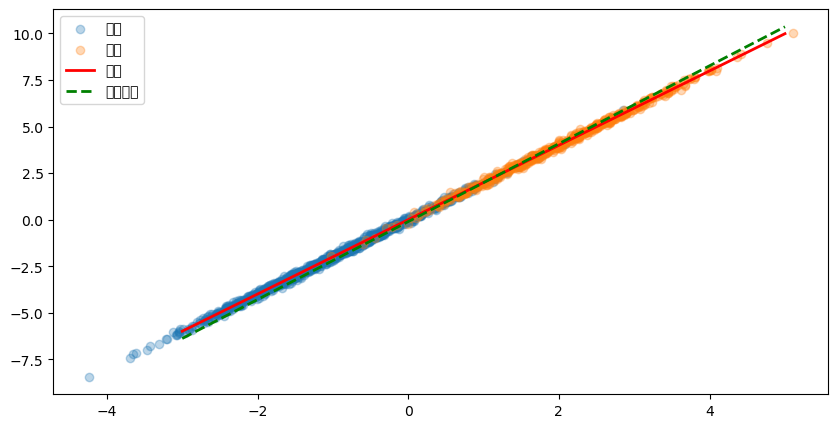

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import mean_squared_error

np.random.seed(42)
print("=" * 60)
print("协变量偏移实验")
print("=" * 60)

n_train, n_test = 1000, 500
x_train = np.random.normal(-1.0, 1.0, n_train)
y_train = 2.0 * x_train + np.random.normal(0, 0.1, n_train)
x_test = np.random.normal(2.0, 1.0, n_test)
y_test = 2.0 * x_test + np.random.normal(0, 0.1, n_test)

# 基线模型
model_base = LinearRegression()
model_base.fit(x_train.reshape(-1,1), y_train)
y_pred_base = model_base.predict(x_test.reshape(-1,1))
mse_base = mean_squared_error(y_test, y_pred_base)

# 重要性权重
X_all = np.vstack([x_train.reshape(-1,1), x_test.reshape(-1,1)])
y_all = np.array([0]*n_train + [1]*n_test)
clf = LogisticRegression()
clf.fit(X_all, y_all)
prob_test = clf.predict_proba(x_train.reshape(-1,1))[:,1]
weights = prob_test / (1 - prob_test + 1e-8)
weights /= weights.sum()
weights *= n_train

# 加权回归
X_mat = np.column_stack([x_train, np.ones(n_train)])
W = np.diag(weights)
theta = np.linalg.pinv(X_mat.T @ W @ X_mat) @ (X_mat.T @ W @ y_train)
a, b = theta
y_pred_w = a * x_test + b
mse_w = mean_squared_error(y_test, y_pred_w)

print(f"基线模型 MSE: {mse_base:.4f}")
print(f"加权校正 MSE: {mse_w:.4f}")
print(f"性能提升: {(mse_base - mse_w)/mse_base * 100:.2f}%")

plt.figure(figsize=(10,5))
plt.scatter(x_train, y_train, alpha=0.3, label='训练')
plt.scatter(x_test, y_test, alpha=0.3, label='测试')
x_line = np.linspace(-3,5,100)
plt.plot(x_line, model_base.predict(x_line.reshape(-1,1)), 'r-', linewidth=2, label='基线')
plt.plot(x_line, a*x_line + b, 'g--', linewidth=2, label='加权校正')
plt.legend()
plt.show()